In [1]:
import pandas as pd 

# Distribution pour la Hongrie 

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Lire le dataset
df = pd.read_csv('hongrie_concatene.csv')

# Convertir la colonne 'Datetime (UTC)' en datetime
df['Datetime (UTC)'] = pd.to_datetime(df['Datetime (UTC)'])

# Trier les données par date
df = df.sort_values(by='Datetime (UTC)')

# Calculer la variation quotidienne de la colonne 'Carbon Intensity gCO₂eq/kWh (LCA)'
df['Variation'] = df['Carbon Intensity gCO₂eq/kWh (LCA)'].diff(1)



# Définir la date du conflit en Ukraine
date_conflit = pd.to_datetime('2022-02-24')
date_419_apres_conflit = pd.to_datetime('2023-04-19')

# Séparer les données avant et après le conflit
df_avant_conflit = df[df['Datetime (UTC)'] < date_conflit]
df_apres_conflit = df[(df['Datetime (UTC)'] > date_conflit) & (df['Datetime (UTC)'] <= date_419_apres_conflit)]


In [23]:
len(df_avant_conflit), len(df_apres_conflit)

(419, 419)

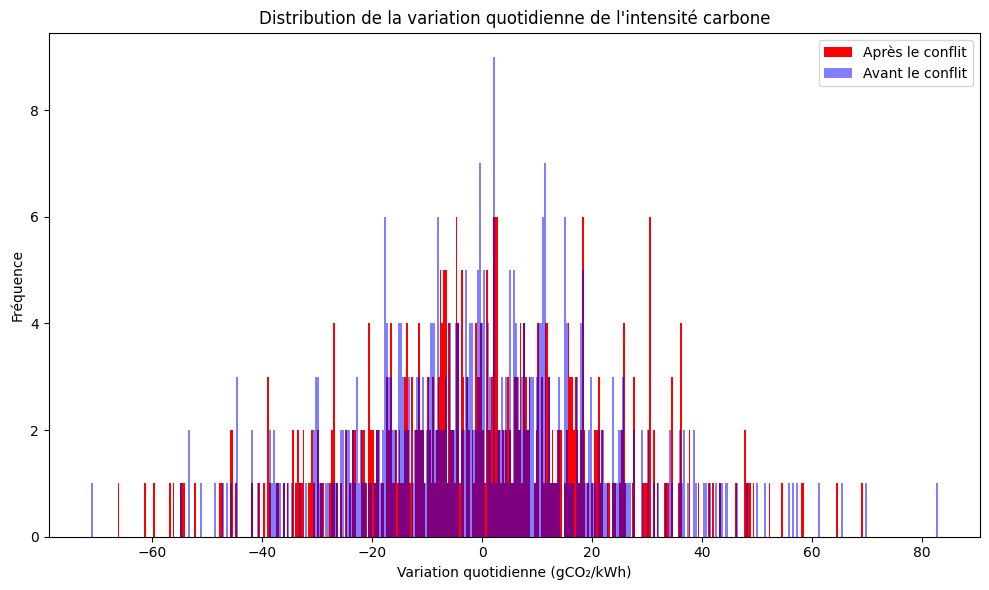

In [44]:

# Tracer les distributions de la variation quotidienne avant et après le conflit avec transparence
plt.figure(figsize=(10, 6))

# Tracer l'histogramme de la variation quotidienne après le conflit avec transparence
plt.hist(df_apres_conflit['Variation'].dropna(), bins=419, color='red', alpha=1., label='Après le conflit')
# Tracer l'histogramme de la variation quotidienne avant le conflit avec transparence
plt.hist(df_avant_conflit['Variation'].dropna(), bins=419, color='blue', alpha=0.5, label='Avant le conflit')


# Ajouter les labels et la légende
plt.title('Distribution de la variation quotidienne de l\'intensité carbone')
plt.xlabel('Variation quotidienne (gCO₂/kWh)')
plt.ylabel('Fréquence')
plt.legend(loc='upper right')

# Afficher le graphique
plt.tight_layout()
plt.show()



même nombre de points dans chaque couleur
on compare des semaines, à voir si la moyenne glissante peut se faire à une autre maille. 


In [43]:
var_pos_av, var_neg_av = df_avant_conflit[df_avant_conflit['Variation'] > 0]['Variation'].sum(), df_avant_conflit[df_avant_conflit['Variation'] < 0]['Variation'].sum()
var_pos_ap, var_neg_ap = df_apres_conflit[df_apres_conflit['Variation'] > 0]['Variation'].sum(), df_apres_conflit[df_apres_conflit['Variation'] < 0]['Variation'].sum()

print(f"Variation positive avant le conflit : {var_pos_av}")
print(f"Variation négative avant le conflit : {var_neg_av}")
print(f"Variation positive après le conflit : {var_pos_ap}")
print(f"Variation négative après le conflit : {var_neg_ap}")
# Calculer la variation totale avant et après le conflit
var_tot_av = df_avant_conflit['Variation'].sum()    
var_tot_ap = df_apres_conflit['Variation'].sum()
print(f"Variation totale avant le conflit : {var_tot_av}")
print(f"Variation totale après le conflit : {var_tot_ap}")
# Calculer la variation totale avant et après le conflit
print(f"Variation de variatino négative dûe à la guerre : {100*(var_neg_ap/(var_neg_av+var_neg_ap)):.2f}%")

Variation positive avant le conflit : 3544.5999999999995
Variation négative avant le conflit : -3475.7
Variation positive après le conflit : 3631.1499999999996
Variation négative après le conflit : -3693.09
Variation totale avant le conflit : 68.89999999999998
Variation totale après le conflit : -61.93999999999997
Variation de variatino négative dûe à la guerre : 51.52%


In [4]:
import pandas as pd

# Lire le dataset
df = pd.read_csv('hongrie_concatene.csv')

# Convertir la colonne 'Datetime (UTC)' en datetime
df['Datetime (UTC)'] = pd.to_datetime(df['Datetime (UTC)'])

# Trier les données par date
df = df.sort_values(by='Datetime (UTC)')

# Définir la date du conflit en Ukraine
date_conflit = pd.to_datetime('2022-02-24')

# Séparer les données avant et après le conflit
df_avant_conflit = df[df['Datetime (UTC)'] < date_conflit]
df_apres_conflit = df[df['Datetime (UTC)'] >= date_conflit]

# Calculer la moyenne pour chaque période
moyenne_avant_conflit = df_avant_conflit['Carbon Intensity gCO₂eq/kWh (LCA)'].mean()
moyenne_apres_conflit = df_apres_conflit['Carbon Intensity gCO₂eq/kWh (LCA)'].mean()

# Afficher les résultats
print(f"Moyenne avant le conflit (2022-02-24) : {moyenne_avant_conflit}")
print(f"Moyenne après le conflit (2022-02-24) : {moyenne_apres_conflit}")


Moyenne avant le conflit (2022-02-24) : 304.0844630071599
Moyenne après le conflit (2022-02-24) : 262.735508637236


# Distribution pour la France

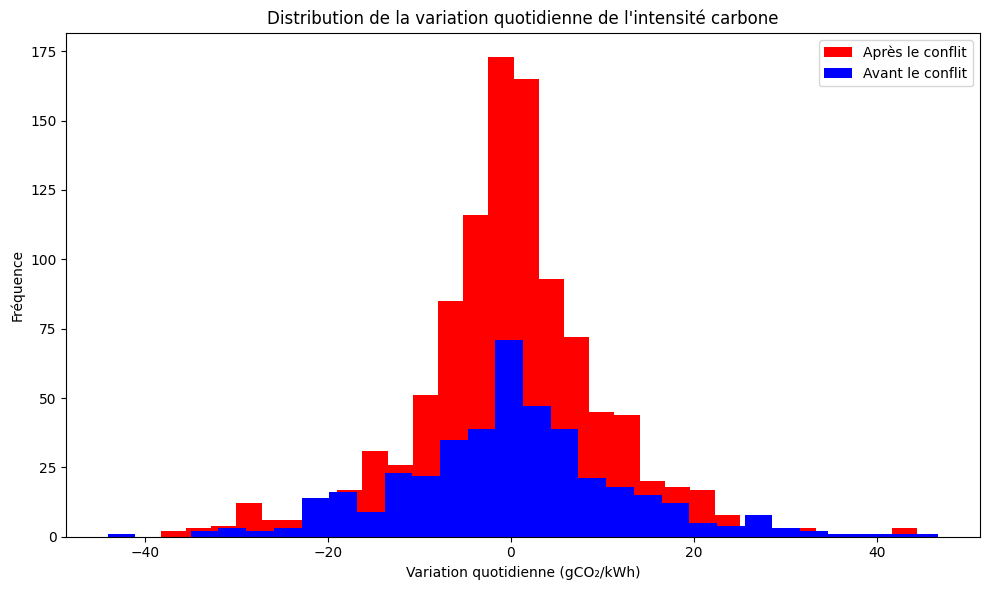

In [6]:
# Lire le dataset
dff = pd.read_csv('france_concatene.csv')

# Convertir la colonne 'Datetime (UTC)' en datetime
dff['Datetime (UTC)'] = pd.to_datetime(df['Datetime (UTC)'])

# Trier les données par date
dff = dff.sort_values(by='Datetime (UTC)')

# Calculer la variation quotidienne de la colonne 'Carbon Intensity gCO₂eq/kWh (LCA)'
dff['Variation'] = dff['Carbon Intensity gCO₂eq/kWh (LCA)'].diff()

# Définir la date du conflit en Ukraine
date_conflit = pd.to_datetime('2022-02-24')

# Séparer les données avant et après le conflit
dff_avant_conflit = dff[dff['Datetime (UTC)'] < date_conflit]
dff_apres_conflit = dff[dff['Datetime (UTC)'] >= date_conflit]

# Tracer les distributions de la variation quotidienne avant et après le conflit avec transparence
plt.figure(figsize=(10, 6))

# Tracer l'histogramme de la variation quotidienne après le conflit avec transparence
plt.hist(dff_apres_conflit['Variation'].dropna(), bins=30, color='red', alpha=1., label='Après le conflit')

# Tracer l'histogramme de la variation quotidienne avant le conflit avec transparence
plt.hist(dff_avant_conflit['Variation'].dropna(), bins=30, color='blue', alpha=1., label='Avant le conflit')



# Ajouter les labels et la légende
plt.title('Distribution de la variation quotidienne de l\'intensité carbone')
plt.xlabel('Variation quotidienne (gCO₂/kWh)')
plt.ylabel('Fréquence')
plt.legend(loc='upper right')

# Afficher le graphique
plt.tight_layout()
plt.show()

### Idées de régression sur séries temporelles

- arima, sarima, arimax pour comparer prédictions 
- 